# Projet Ralstonia solanacearum avec CobraPy

Dans ce notebook, je construis progressivement un modèle FBA/FVA pour *Ralstonia solanacearum* à partir d'un fichier SBML, en m'inspirant du tutoriel CobraPy mais en adaptant toutes les étapes à ce réseau.

## Question 1:  Charger (créer) le modèle SBML dans CobraPy

Je commence par importer les bibliothèques nécessaires et par créer l'objet 'model'
à partir du fichier SBML de l'espèce.


In [16]:
import cobra
from cobra.io import read_sbml_model
import pandas as pd
pd.options.display.max_rows = 100  # Pour afficher proprement les tableaux plus tard

# Je lis le fichier SBML de Ralstonia
model = read_sbml_model("ralsto_metexplore3.xml")

# Résumé brut de l'objet modèle pour vérifier que le chargement a fonctionné
model


Adding exchange reaction EX_hdcea_b with default bounds for boundary metabolite: hdcea_b.
Adding exchange reaction EX_RSc1944_b with default bounds for boundary metabolite: RSc1944_b.
Adding exchange reaction EX_3oochslac_b with default bounds for boundary metabolite: 3oochslac_b.
Adding exchange reaction EX_glu_D_b with default bounds for boundary metabolite: glu_D_b.
Adding exchange reaction EX_RipS4_b with default bounds for boundary metabolite: RipS4_b.
Adding exchange reaction EX_fecrm_b with default bounds for boundary metabolite: fecrm_b.
Adding exchange reaction EX_ni2_b with default bounds for boundary metabolite: ni2_b.
Adding exchange reaction EX_RipK_b with default bounds for boundary metabolite: RipK_b.
Adding exchange reaction EX_berb_b with default bounds for boundary metabolite: berb_b.
Adding exchange reaction EX_tartr_L_b with default bounds for boundary metabolite: tartr_L_b.
Adding exchange reaction EX_octa_b with default bounds for boundary metabolite: octa_b.
Addi

Name,_bc9d1403_3bf5_4994_8369_f3c28ce8995a
Memory address,7f1b8dbe8560
Number of metabolites,2574
Number of reactions,3097
Number of genes,2219
Number of groups,253
Objective expression,0
Compartments,"boundary, extracellular, cytoplasm, periplasm"


## Question 2 : La taille du réseau; les réactions, métabolites, gènes

Comptage des composantes principales du modèle : nombre de réactions, nombre de métabolites et nombre de gènes.



In [17]:
nb_of_reactions = len(model.reactions)
nb_of_metabolites = len(model.metabolites)
nb_of_genes = len(model.genes)

print("Nombre de réactions   :", nb_of_reactions) # Le nombre de réactions dans model.reactions est “réseau original + quelques réactions d’échange auto-ajoutées”.
print("Nombre de métabolites :", nb_of_metabolites)
print("Nombre de gènes       :", nb_of_genes)


Nombre de réactions   : 3097
Nombre de métabolites : 2574
Nombre de gènes       : 2219


Notons que CobraPy ajoute automatiquement une réaction d’échange pour les métabolites marqués 'boundaryCondition = true' dans le SBML mais qui n’ont pas encore de réaction d’échange. Ce qui augmente le nombre total de réactions par rapport au fichier SBML initial.


## Question 3 : Indiquer la réaction de biomasse comme fonction objectif

Je recherche d'abord quelle est la réaction de biomasse: dans le modèle CobraPy, puis je la définis comme fonction objectif du modèle.


In [18]:
# Je retrouve la réaction dont l'identifiant contient le mot "BIOMASS"
biomass_elements = []
for reaction in model.reactions: # je parcours toutes les réactions du modèle
    reactions_id = reaction.id.upper()
    
    if "BIOMASS" in reactions_id:
        biomass_elements.append(reaction.id)
        
biomass_elements


['BIOMASS']

In [48]:
# Je stocke l'ID de la réaction de biomasse trouvé ci-dessus
biomass_id = "BIOMASS"  

# Je définis cette réaction comme fonction objectif du modèle
model.objective = biomass_id

# Je teste si l'objectif est bien pris en compte par CobraPy en le demandant
model.objective.expression


1.0*BIOMASS - 1.0*BIOMASS_reverse_69053

La réaction BIOMASS représente la croissance (la synthèse de tous les constituants de la cellule), donc en la mettant comme objectif, nous maximisons le flux qui traverse cette réaction; ainsi donc, parmi toutes les façons possibles de faire fonctionner le réseau, on maximise celle où la cellule pousse le plus vite.

## Question 4 : Mettre à 0 la "lower bound" de toutes réactions d’échange du modèle (Fermer toutes les réactions d’échange)

Dans CobraPy, les réactions d’échange du modèle sont accessibles via l’attribut 'model.exchanges' comme évoqué dans l'énoncé.  
Je ferme d’abord toutes les entrées en mettant leur 'lower_bound' à 0 (aucun métabolite ne peut entrer).

In [20]:
for reaction in model.exchanges:
    reaction.lower_bound=0
for reaction in model.exchanges[:10]: # Je check les 10 premières réactions d'échange visuellement
    print(reaction.id, "lb =", reaction.lower_bound, "ub =", reaction.upper_bound)

EX_hdcea_b lb = 0 ub = 1000.0
EX_RSc1944_b lb = 0 ub = 1000.0
EX_3oochslac_b lb = 0 ub = 1000.0
EX_glu_D_b lb = 0 ub = 1000.0
EX_RipS4_b lb = 0 ub = 1000.0
EX_fecrm_b lb = 0 ub = 1000.0
EX_ni2_b lb = 0 ub = 1000.0
EX_RipK_b lb = 0 ub = 1000.0
EX_berb_b lb = 0 ub = 1000.0
EX_tartr_L_b lb = 0 ub = 1000.0


## Question 5 : Fixer les lb et ub des réactions d’échange faisant intervenir les métabolites donnés
Ceci revient à autoriser les échanges pour certains métabolites (libres d'entrer et de sortir du système)

In [21]:
exchange_metabolites= ["h2o_b", "h_b", "k_b", "pi_b", "na1_b", "nh4_b", "so4_b", "mg2_b", "cl_b", "fe2_b", "fe3_b", "cobalt2_b", "mn2_b", "mobd_b", "o2_b", "co2_b"]

for met in exchange_metabolites:
    reactions_id= "EX_" + met
    
    # je récupère dans le modèle la réaction qui porte exactement cet ID
    reaction = model.reactions.get_by_id(reactions_id)
    reaction.lower_bound=-1000 # comme l'enoncé demande
    reaction.upper_bound=1000

    print("La Réaction", reaction.id, " a son : lb =", reaction.lower_bound, ", et son ub =", reaction.upper_bound)

La Réaction EX_h2o_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_h_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_k_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_pi_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_na1_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_nh4_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_so4_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_mg2_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_cl_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_fe2_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_fe3_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_cobalt2_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_mn2_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_mobd_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_o2_b  a son : lb = -1000 , et son ub = 1000
La Réaction EX_co2_b  a son : lb = -1000 , et son ub = 1000


## Question 6 : Pourquoi met-on le flux lower bound à 0 pour toutes les réactions d’échange sauf pour les réactions faisant intervenir certains métabolites ?

On met le lower bound à 0 pour toutes les réactions d’échange (sauf quelques-unes) afin de représenter le fait que, dans le milieu que l’on définit, la plupart des métabolites ne sont pas directement disponibles dans l’environnement. Un flux d’échange négatif correspond à une entrée dans la cellule or si la borne inférieure est 0, cette entrée est impossible, donc le modèle ne peut pas importer ce métabolite. 
On autorise un lower bound négatif uniquement pour certains composés inorganiques (eau, ions, sels minéraux et autres) qui font partie du milieu de culture choisi ; ce sont eux qui peuvent réellement être fournis par l’environnement pour permettre la croissance optimale, alors que les autres doivent être synthétisés par la cellule à partir de ces nutriments.

Une autre manière de penser est qu'on force le modèle à ne compter que sur un petit groupe de nutriments que l’on autorise à entrer (ceux pour lesquels on met un lower bound négatif), et on peut ainsi analyser de façon plus propre de quels composés la croissance dépend vraiment. C’est donc à la fois une manière de *définir le milieu et une manière de sonder la dépendance du réseau à certains métabolites*.


## Question 7 : Fixer les flux des réactions données aux valeurs fournies

Je fixe le flux de deux réactions :
- 'NGAME' à 8.39 (consommation d’ATP pour la maintenance),
- 'FEOXpp' à 0 (je bloque cette réaction pour éviter de l’ATP 'gratuit')
Pour cela, je mets leur 'lower_bound' et 'upper_bound' à la même valeur.

In [22]:
# 1) Réaction NGAME : flux forcé à 8.39
Reaction_NGAME = model.reactions.get_by_id("NGAME")
Reaction_NGAME.lower_bound = 8.39
Reaction_NGAME.upper_bound = 8.39

# 2) Réaction FEOXpp : flux forcé à 0
Reaction_FEOXpp = model.reactions.get_by_id("FEOXpp")
Reaction_FEOXpp.lower_bound = 0
Reaction_FEOXpp.upper_bound = 0

# Contrôle par l'affichage
print("Pour NGAME : lb =", Reaction_NGAME.lower_bound, ", ub =", Reaction_NGAME.upper_bound)
print("Pour FEOXpp : lb =", Reaction_FEOXpp.lower_bound, ", ub =", Reaction_FEOXpp.upper_bound)

Pour NGAME : lb = 8.39 , ub = 8.39
Pour FEOXpp : lb = 0 , ub = 0


## Question 8 : Calculer le taux de croissance dans les conditions ci-dessus.

NB: Le solveur par défaut utilisé était CPLEX.
Pour le modèle à l’échelle du génome de R.solanacearum, la taille du problème dépasse les limites de la version gratuite de CPLEX (erreur).
J’ai donc basculé sur le solveur linéaire libre GLPK, supporté par CobraPy, ce qui permet de résoudre le modèle complet.

In [23]:
model_test1= model.copy() # je garde une copie du modele initial
model_test1.solver = "glpk"

taux_de_croissance = model_test1.optimize() # Exécution de FBA
print("Le statut du flux :", taux_de_croissance.status)
print("Taux de croissance ou biomasse :", taux_de_croissance.objective_value)

Le statut du flux : infeasible
Taux de croissance ou biomasse : 0.0


/home/hlannon/miniforge3/lib/python3.12/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Dans ces conditions, le solveur indique que le problème est infaisable c'est à dire qu'il n’existe aucune distribution de flux qui respecte à la fois les bilans de masse et toutes les bornes imposées.
En pratique, le milieu ne contient que des sels minéraux et des gaz, aucune vraie source de carbone organique. La cellule n’a donc rien à consommer pour fabriquer de la biomasse.
En plus, on impose un flux de maintenance (NGAME = 8.39) qui consomme de l’ATP. Sans substrat carboné pour produire cette énergie, le modèle ne peut même pas assurer la maintenance, par conséquent, il n’y a aucun état stationnaire possible, d’où le statut infeasible et un taux de croissance nul.

## Question 9 : Fixer le flux lower bound et upper des réactions de transports des métabolites donnés, aux valeurs fournies 

Le sujet evoque les métabolites, mais pas des id de réactions, regardons d’abord à quelles réactions chaque métabolite participe :

In [11]:
metab_ids_given = ["glu_L_b", "3ohpame_b", "EPS_b", "ptrc_b", "Tek_28kd_b", "etle_b"]

for metab_id in metab_ids_given:
    metabolites = model.metabolites.get_by_id(metab_id)
    print("Pour le Métabolite :", metab_id)
    for reaction in metabolites.reactions:
        print("La reaction ", reaction.id, "correspond à :", reaction.reaction)
    print() # ligne d'espacement

Pour le Métabolite : glu_L_b
La reaction  EX_glu_L_e_ correspond à : glu_L_e <=> glu_L_b
La reaction  EX_glu_L_b correspond à : glu_L_b --> 

Pour le Métabolite : 3ohpame_b
La reaction  EX_3ohpame_b correspond à : 3ohpame_b --> 
La reaction  EX_3OHPAMES_e_ correspond à : 3ohpame_e <=> 3ohpame_b

Pour le Métabolite : EPS_b
La reaction  EX_EPS_e_ correspond à : EPS_e <=> EPS_b
La reaction  EX_EPS_b correspond à : EPS_b --> 

Pour le Métabolite : ptrc_b
La reaction  EX_ptrc_e_ correspond à : ptrc_e <=> ptrc_b
La reaction  EX_ptrc_b correspond à : ptrc_b --> 

Pour le Métabolite : Tek_28kd_b
La reaction  EX_Tek_28kd_b correspond à : Tek_28kd_b --> 
La reaction  EX_Tek_e_ correspond à : Tek_28kd_e <=> Tek_28kd_b

Pour le Métabolite : etle_b
La reaction  EX_etle_e_ correspond à : etle_e <=> etle_b
La reaction  EX_etle_b correspond à : etle_b --> 



EX_glu_L_b : glu_L_b <=> : reaction d'échange mais pas de transport physique et glu_L_e <=> glu_L_b : reaction de transport entre deux compartiments 

Ensuite on va fixer les flux sur les réactions qui représentent le transport de métabolite vers l’extérieur, en utilisant les valeurs fournies dans l’énoncé.

In [25]:
flux_react_transport = {
    "EX_glu_L_b":   -8.25, # format du dictionnaire : {id de la réaction : le flux imposé}
    "EX_3ohpame_b": 1.5e-4,
    "EX_EPS_b":     0.0062,
    "EX_ptrc_b":    0.28,
    "EX_Tek_28kd_b":2.7e-4,
    "EX_etle_b":    0.0129,}

for reaction_id, value in flux_react_transport.items():
    reaction = model.reactions.get_by_id(reaction_id)   # je récupère la réaction par son ID
    reaction.lower_bound = value   # je fixe la borne inférieure à la valeur de la clé
    reaction.upper_bound = value   # et la borne supérieure à la même valeur  
    print(f"Le flux de la réaction {reaction.id} est fixée à {value}")


Le flux de la réaction EX_glu_L_b est fixée à -8.25
Le flux de la réaction EX_3ohpame_b est fixée à 0.00015
Le flux de la réaction EX_EPS_b est fixée à 0.0062
Le flux de la réaction EX_ptrc_b est fixée à 0.28
Le flux de la réaction EX_Tek_28kd_b est fixée à 0.00027
Le flux de la réaction EX_etle_b est fixée à 0.0129


Le taux de croissance dans les conditions fixées ci-dessus + Ma deduction

In [27]:
model.solver = "glpk"
model_test2= model.copy()

Taux_de_croissance_rich_env = model_test2.optimize()
print("Le statut du flux :", Taux_de_croissance_rich_env.status)
print("Taux de croissance ou biomasse :", Taux_de_croissance_rich_env.objective_value)
model_test2.summary()

Le statut du flux : optimal
Taux de croissance ou biomasse : 0.5119279935093638


Metabolite,Reaction,Flux,C-Number,C-Flux
cl_b,EX_cl_b,0.002665,0,0.00%
cobalt2_b,EX_cobalt2_b,0.000127,0,0.00%
fe2_b,EX_fe2_b,0.004225,0,0.00%
glu_L_b,EX_glu_L_b,8.25,0,0.00%
h_b,EX_h_b,14.44,0,0.00%
k_b,EX_k_b,0.09992,0,0.00%
mg2_b,EX_mg2_b,0.004441,0,0.00%
mn2_b,EX_mn2_b,0.0003537,0,0.00%
mobd_b,EX_mobd_b,6.604E-05,0,0.00%
o2_b,EX_o2_b,13.4,0,0.00%


Dans la question 9, on a ajouté des contraintes de flux basées sur des mesures expérimentales pour plusieurs métabolites. Ces flux correspondent cette fois ci à de vrais apports et excrétions de composés organiques.
Avec ces nouvelles contraintes, le modèle trouve une solution faisable et le statut devient optimal; le taux de croissance est d’environ 0,51/h.
Autrement dit, dès qu’on fournit au modèle un milieu plus réaliste contenant des substrats organiques (comme le glutamate, source directe de carbone et d’azote) et pas seulement des sels minéraux, il est capable de couvrir la maintenance et de produire aussi de la biomasse. La différence entre les contraintes des Question 8 et Q9 montre bien que la croissance est limitée avant tout par la disponibilité en nutriments organiques.

## Question 10 : Calculer la valeur du flux de la réaction NGAME pour atteindre ce taux de croissance en FBA. Quelle est cette valeur ?


In [30]:
model_test3 = model.copy()

# Je récupère la réaction de biomasse
Biomass_reaction = model_test3.reactions.get_by_id("BIOMASS")

# Je fixe le flux de biomasse au taux expérimental : 0.28
Biomass_reaction.lower_bound = 0.28  # la biomasse ne peut pas être < 0.28
Biomass_reaction.upper_bound = 0.28  # la biomasse ne peut pas être > 0.28

# Je récupère la réaction de maintenance NGAME
Ngame_reaction = model_test3.reactions.get_by_id("NGAME")

# Precedemment fixé à 8.39, je mets desormais NGAME dans un intervalle logique
Ngame_reaction.lower_bound = 0.0      # car le flux de consommation d’ATP ne peut etre négatif
Ngame_reaction.upper_bound = 800    # borne superieure bien ouverte

# Respectant la logique de la question, je définis la fonction objectif au flux minimal de la reacrion NGAME
model_test3.objective = Ngame_reaction   
model_test3.objective_direction = "min"    # minimiser le flux de cette reaction

# Optimisation
solution_test3 = model_test3.optimize()
print("Le statut de la solution_test3 :", solution_test3.status)

if solution_test3.status == "optimal":
    # La valeur de NGAME trouvée correspond donc la maintenance minimale compatible avec une croissance de 0.28
    flux_NGAME = solution_test3.fluxes["NGAME"]
    print("Le flux minimal de la reaction NGAME pour une croissance de 0.28/h est de :", flux_NGAME)
else:
    print("Le modèle est infaisable dans ces conditions, pas de solution avec biomasse à 0.28")

Le statut de la solution_test3 : optimal
Le flux minimal de la reaction NGAME pour une croissance de 0.28/h est de : 0.0


Méthode Parcimonieuse:
Afin d'estimer le flux de la réaction de maintenance NGAME correspond au taux de croissance expérimental de 0,28/h, j’ai dû imposer le flux de la réaction de biomasse à 0,28 (lb = ub = 0,28), puis j’ai choisi NGAME comme la nouvelle fonction objectif en le minimisant. Ainsi, cette approche est la plus parcimonieuse car, parmi toutes les distributions de flux capables de soutenir une croissance de 0,28/h dans les conditions de la question 9, on sélectionne celle qui consomme le moins d’ATP de maintenance (flux minimal de NGAME).


Puisque le flux minimal de la reaction NGAME pour une croissance de 0.28/h est de : 0.0 ; on deduit que dans notre modèle actuel, il existe au moins une distribution de flux qui atteint une croissance de 0,28/h sans passer par la réaction NGAME. Autrement dit, dans le modèle ci-dessus tel que construit, la réaction NGAME n’est pas nécessaire pour atteindre cette croissance, parce que les coûts énergétiques minimums seraient déjà couverts par d’autres réactions.

## Question 11 : Sauvegarder les flux dans un fichier tabulé avec préfixe ("R_" sur les IDs de réactions car cest ce que MetExplore attend) et les mapper sur les arêtes du sous-réseau métabolique de la glycolyse de Ralstonia dans MetExplore 3.

In [42]:
import pandas as pd

# Je récupère les flux de la solution FBA du scénario Question 9
Saved_flux = Taux_de_croissance_rich_env.fluxes # "fluxes" est une Series pandas où index = id de réaction et valeur = flux numérique

# Je transforme le resultat en dataFrame pour avoir un tableau 
Table_of_flux = Saved_flux.to_frame(name="flux") #  avec nettement une colonne "flux" avec les valeur du flux FBA pour chaque réaction

# Pour plus de clarté, je renomme l'index aussi dans une vraie colonne
Table_of_flux = Table_of_flux.reset_index()
Table_of_flux.columns = ["reaction_id_initial", "flux"]

# MetExplore veut des id de réactions avec un préfixe "R_", je crée donc une nouvelle colonne "reaction_id" en ajoutant ce préfixe
Table_of_flux["reaction_id"] = "R_" + Table_of_flux["reaction_id_initial"].astype(str)

# je ne garde que les colonnes utiles pour MetExplore, une colonne pour l'id et une colonne pour la valeur de flux
Table_of_flux_for_export = Table_of_flux[["reaction_id", "flux"]]

# Je sauvegarde ce tableau dans un fichier .tsv
output_filename = "flux_scénario_Question_9.tab"
Table_of_flux_for_export.to_csv(output_filename, sep="\t", index=False)

print("Les premières lignes du tableau :")
Table_of_flux_for_export.head(21)


Les premières lignes du tableau :


,reaction_id,flux
0,R_EX_hdcea_b,0.000000
1,R_EX_RSc1944_b,0.000000
2,R_EX_3oochslac_b,0.000000
3,R_EX_glu_D_b,0.000000
4,R_EX_RipS4_b,0.000000
5,R_EX_fecrm_b,0.000000
6,R_EX_ni2_b,0.000000
7,R_EX_RipK_b,0.000000
8,R_EX_berb_b,0.000000
9,R_EX_tartr_L_b,0.000000


Affichons le graphe du mapping du flux des reactions (Q9) sur la glycolyse de Ralstonia

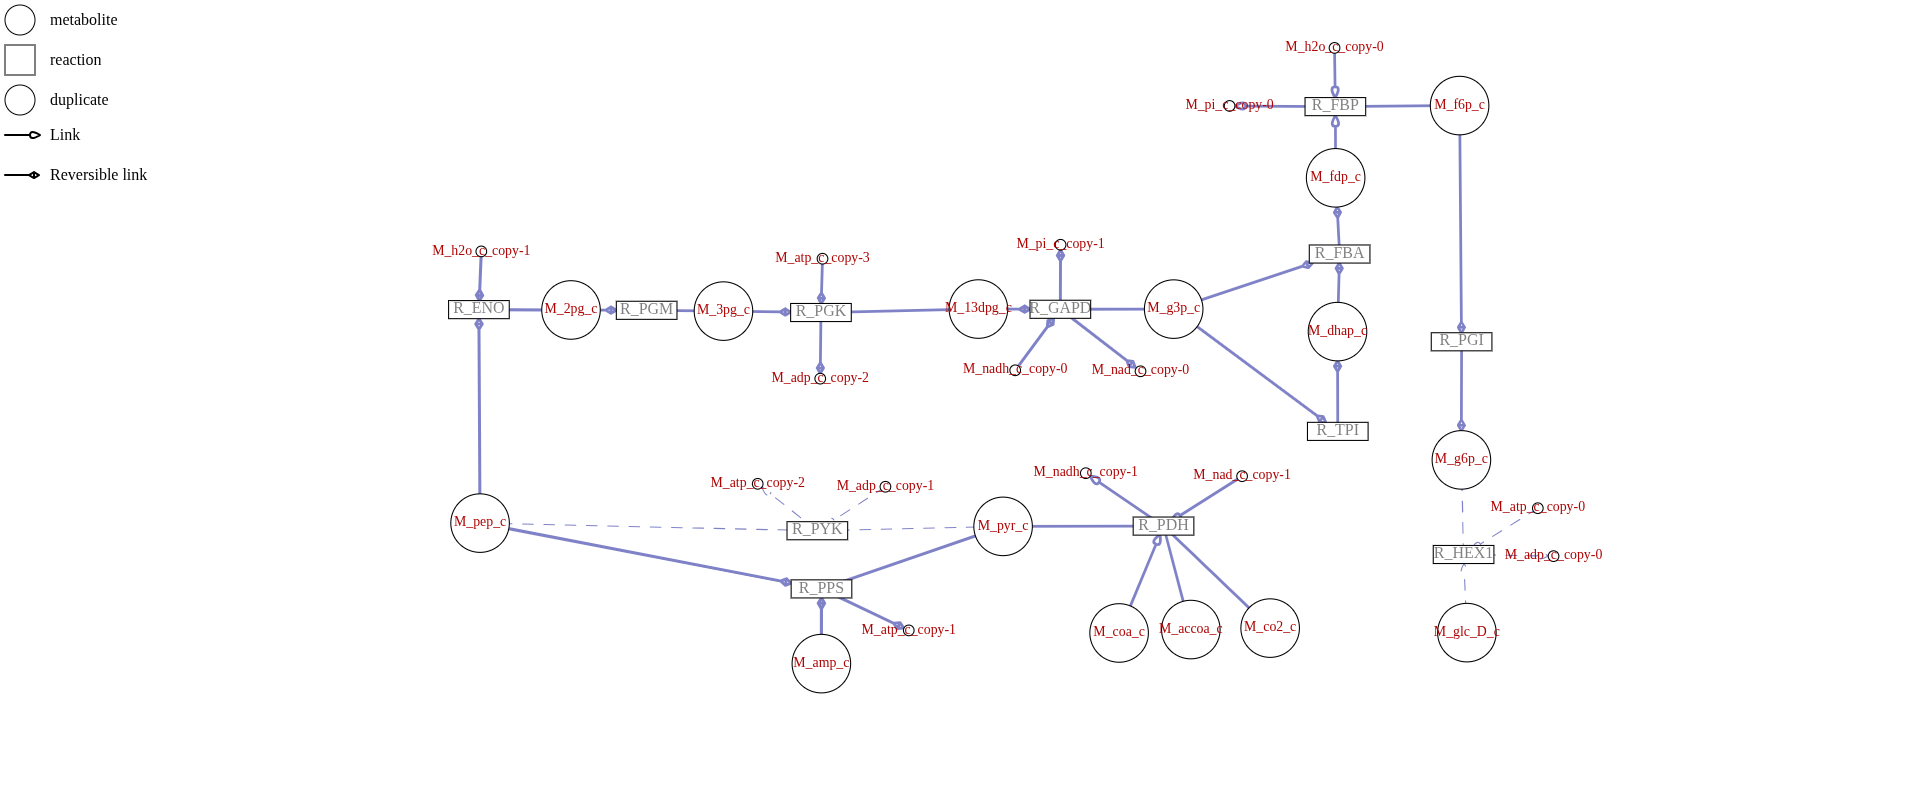

In [43]:
from IPython.display import Image
Image(filename="graph_mapping_fluxQ9_GLYCOLYSE_ok.png")


## Question 12 : Déterminer les gènes essentiels qui permettent la croissance optimale obtenue dans la question 9.
Rappelons que les gènes essentiels sont ceux pour lesquels la croissance simulée après une inactivation totale 
est pratiquement nulle. Autrement dit ce sont les gènes dont la perte bloquerait totalement la production de biomasse dans les conditions décrites dans la question 9.    

In [56]:
from cobra.flux_analysis import single_gene_deletion

# En partant du modèle de la question 9 je vérifie que l'objectif est bien la biomasse
model_test2.objective = biomass_id
print("objectif actuel :", model_test2.objective.expression)

# Je vérifie aussi pour commencer que la croissance optimale n'est pas nulle dans ce scénario
print("Taux de croissance ou biomasse :", Taux_de_croissance_rich_env.objective_value)

objectif actuel : 1.0*BIOMASS - 1.0*BIOMASS_reverse_69053
Taux de croissance ou biomasse : 0.5119279935093638


In [59]:
results_of_gene_inactivation = single_gene_deletion(model_test2, processes=1)
results_of_gene_inactivation.head(10)

,ids,growth,status
0,{RSc2780},0.000000e+00,optimal
1,{e0140},5.119280e-01,optimal
2,{RSc1733},5.119280e-01,optimal
3,{RSp0822},5.119280e-01,optimal
4,{e0360},5.119280e-01,optimal
5,{s0054},5.119280e-01,optimal
6,{RSp1530},5.119280e-01,optimal
7,{d0024},5.119280e-01,optimal
8,{RSc2110},6.125030e-15,optimal
9,{RSp1364},5.119280e-01,optimal


In [81]:
# je définis un seuil en dessous duquel je considère la croissance comme nulle
seuil_croissance = 1e-5

# Je sélectionne les gènes pour lesquels la croissance après l'inactivation est nulle
jeu_donnees_genes_essentiels = results_of_gene_inactivation[results_of_gene_inactivation["growth"] < seuil_croissance]

print("Nous avons :", len(jeu_donnees_genes_essentiels), "gènes essentiels dans ce milieu")
jeu_donnees_genes_essentiels.head(10)

Nous avons : 197 gènes essentiels dans ce milieu


,ids,growth,status
0,{RSc2780},0.000000e+00,optimal
8,{RSc2110},6.125030e-15,optimal
10,{d0081},-1.746261e-17,optimal
12,{RSc2976},0.000000e+00,optimal
17,{e0009},6.283320e-17,optimal
65,{RSc0410},-1.361118e-16,optimal
90,{e0090},-1.774085e-16,optimal
92,{RSc1408},9.264914e-17,optimal
101,{RSc0914},-2.969458e-16,optimal
118,{RSc0574},-5.541815e-14,optimal


In [91]:
# J'extrais la liste d'ids de gènes essentiells
liste_genes_essentiels = []

for ensemble_genes in jeu_donnees_genes_essentiels["ids"]:
    # ensemble_genes est un frozenset du type {'RSc2780'}
    for gene in ensemble_genes:
        liste_genes_essentiels.append(gene)

print("Nombre de gènes essentiels (IDs uniques) :", len(liste_genes_essentiels))
liste_genes_essentiels[:11]


Nombre de gènes essentiels (IDs uniques) : 197


['RSc2780',
 'RSc2110',
 'd0081',
 'RSc2976',
 'e0009',
 'RSc0410',
 'e0090',
 'RSc1408',
 'RSc0914',
 'RSc0574',
 'RSc0109']

In [92]:
table_genes_essentiels = pd.DataFrame({ "gene_id": liste_genes_essentiels,
    "est_essentiel": [True] * len(liste_genes_essentiels)
})
table_genes_essentiels.head()

,gene_id,est_essentiel
0,RSc2780,True
1,RSc2110,True
2,d0081,True
3,RSc2976,True
4,e0009,True


In [93]:
Nom_fichier_genes_essentiels = "Genes_essentiels_pour_flux_q9.tsv"
table_genes_essentiels.to_csv(Nom_fichier_genes_essentiels, sep="\t", index=False)

### Mapping des gènes essentiels dans MetExplore 3

À partir des résultats de l’analyse d’essentialité avec CobraPy, j’ai obtenu une liste de gènes dont le knock-out fait chuter la croissance à presque zéro. Ces gènes sont donc considérés comme essentiels dans ces conditions. J’ai ensuite construit un fichier tabulé contenant pour chaque gène deux informations : son identifiant et un indicateur booléen pour signaler qu’il est essentiel.

Ce fichier a été importé dans MetExplore 3 comme un mapping au niveau des gènes (Mapping on: gene_id). MetExplore fait le lien entre :

- les gènes du fichier de mapping, les réactions métaboliques associées (via les règles gène–protéine–réaction du modèle), et les voies métaboliques dans lesquelles ces réactions se trouvent.

En appliquant ce mapping dans l’outil de visualisation (Display omics data / gene mapping), les gènes essentiels et les réactions qu’ils contrôlent sont mis en évidence sur le réseau de Ralstonia. Cela permet de repérer visuellement dans quelles voies métaboliques se concentrent les gènes essentiels dans le milieu riche (par exemple glycolyse, TCA, biosynthèses clés, etc.). Une capture de cette visualisation est ensuite importée dans le notebook pour illustrer les voies métaboliques contenant ces gènes essentiels.


**J'ai 46 voies métaboliques sur 253 qui ont au moins un gène mappé comme essentiel; listons les après téléchargement du fichier csv correspondant sur MetExplore**

In [102]:
# Je lis le fichier exporté depuis MetExplore
table_voies = pd.read_csv("pathways_involved_ess_genes.csv", sep=",")  

# Je sélectionne la colonne intéressante celle de Name
colonne_interessante = ["Name"]

table_voie_simplifie = table_voies[colonne_interessante]

# les voies enrichies en gènes essentiels
print("Les 46 voies métaboliques contenant des gènes essentiels (après filtrage dans MetExplore) incluent notamment :")
print(table_voie_simplifie["Name"])

Les 46 voies métaboliques contenant des gènes essentiels (après filtrage dans MetExplore) incluent notamment :
0                        Glycine_and_serine_degradation
1                                Putrescine_degradation
2                   Pyridoxal_5__phosphate_biosynthesis
3                                   Purine_biosynthesis
4                               Fatty_acid_biosynthesis
5                                  Thiamin_biosynthesis
6                                   Flavin_biosynthesis
7                               Transport_ion_substrate
8                                      IAA_biosynthesis
9                               Coenzyme_A_biosynthesis
10                                  Folate_biosynthesis
11                              Tryptophan_biosynthesis
12                                   Valine_degradation
13                                    Heme_biosynthesis
14                                Histamine_degradation
15                          Alternate_carbon_meta

Ci-dessous, une capture d’écran (partielle) de MetExplore montrant les pathways principalement enrichis en gènes essentiels dans le scénario de la question 9 :

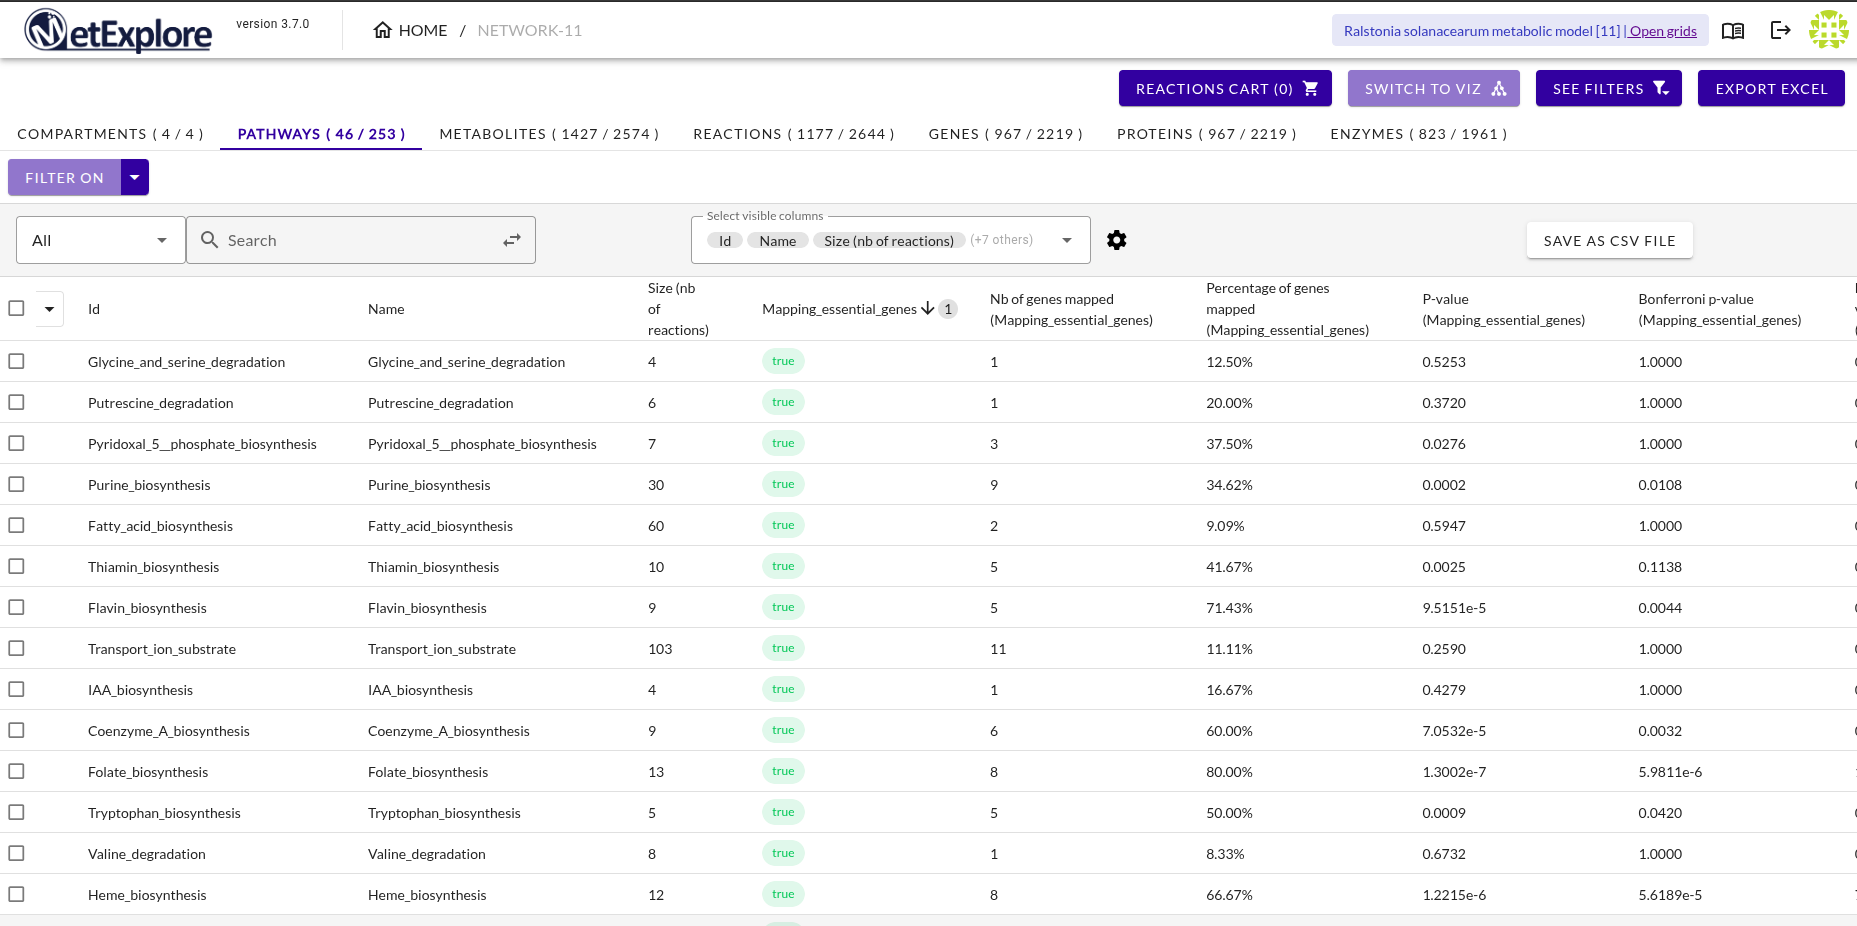

In [103]:
from IPython.display import Image
Image(filename="Mapping_genes_essentiels_ralstonia.png")

Les gènes essentiels ne sont pas regroupés dans une seule voie, mais répartis dans plusieurs voies de biosynthèse clés nécessaires à la vie de Ralstonia (pigments respiratoires, et autres), ce que montrent les pourcentages élevés et les p-values très significatives.